# ECG Anomaly Detection with a PyTorch Autoencoder

## Goal

The goal of this notebook is to build an autoencoder using PyTorch to detect abnormal ECG heartbeat signals.

An autoencoder is trained to reconstruct normal heartbeat patterns. If the model sees an abnormal heartbeat, it should reconstruct it less accurately, producing a higher reconstruction error.

This notebook treats anomaly detection as an unsupervised learning problem:

- Train the autoencoder only on normal heartbeats
- Measure reconstruction error on normal and abnormal heartbeats
- Choose an anomaly threshold
- Evaluate anomaly detection performance

The notebook covers:

- Loading ECG heartbeat data from Kaggle
- Preparing normal and abnormal samples
- Building a dense autoencoder in PyTorch
- Training with reconstruction loss
- Visualizing original vs reconstructed signals
- Calculating reconstruction error
- Choosing thresholds
- Evaluating ROC-AUC, PR-AUC, precision, recall, F1-score
- Inspecting high-error examples

In [1]:
import os
import random
import warnings
from pathlib import Path

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

warnings.filterwarnings("ignore")

SEED = 20

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


device(type='cuda')

## Setup

This notebook uses PyTorch to build and train an autoencoder.

A random seed is set to make the experiment more reproducible.

The notebook also checks whether a GPU is available. The model can run on CPU because the ECG signals are small, but GPU training will usually be faster.

In [2]:
path = kagglehub.dataset_download("shayanfazeli/heartbeat")

print("Dataset downloaded to:", path)
print("Files:")
print(os.listdir(path))

100%|██████████| 98.8M/98.8M [11:51<00:00, 146kB/s]

Extracting files...


Dataset downloaded to: C:\Users\ADMIN\.cache\kagglehub\datasets\shayanfazeli\heartbeat\versions\1
Files:
['mitbih_test.csv', 'mitbih_train.csv', 'ptbdb_abnormal.csv', 'ptbdb_normal.csv']


In [3]:
path = Path(path)

train_path = path / "mitbih_train.csv"
test_path = path / "mitbih_test.csv"

train_df = pd.read_csv(train_path, header=None)
test_df = pd.read_csv(test_path, header=None)

train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Dataset

This notebook uses the ECG Heartbeat Categorization Dataset from Kaggle.

The dataset contains preprocessed heartbeat signals. Each row represents one ECG heartbeat segment.

For the MIT-BIH files, the final column contains the heartbeat class label. The preceding columns contain the signal values across time.

In this notebook, the task is framed as anomaly detection. Class `0` is treated as normal, while all non-zero classes are treated as abnormal.

In [4]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (87554, 188)
Test shape: (21892, 188)


In [7]:
train_labels = train_df.iloc[:, -1]
test_labels = test_df.iloc[:, -1]

print("Train label counts:")
print(train_labels.value_counts().sort_index())

print("\nTest label counts:")
print(test_labels.value_counts().sort_index())

Train label counts:
187
0.0    72471
1.0     2223
2.0     5788
3.0      641
4.0     6431
Name: count, dtype: int64

Test label counts:
187
0.0    18118
1.0      556
2.0     1448
3.0      162
4.0     1608
Name: count, dtype: int64


## Initial Data Inspection

The training set contains 87,554 heartbeat samples and 188 columns.

The test set contains 21,892 heartbeat samples and 188 columns.

The final column is the class label, while the remaining 187 columns represent the ECG signal values.

The original labels contain 5 heartbeat classes:

- Class 0: normal heartbeat
- Classes 1, 2, 3, and 4: abnormal heartbeat types

Class `0` is treated as normal. Classes greater than `0` are treated as abnormal.

The training set contains 72,471 normal samples and 15,083 abnormal samples. The test set contains 18,118 normal samples and 3,774 abnormal samples.

The dataset is imbalanced because normal heartbeats are much more common than abnormal heartbeats. This makes it suitable for anomaly detection, where the model learns normal patterns and identifies signals that do not reconstruct well.

## Binary Anomaly Setup

The original dataset contains multiple heartbeat classes.

For this autoencoder project, the labels are converted into a binary anomaly detection setup:

- `0` = normal heartbeat
- `1` = abnormal heartbeat

The autoencoder will be trained only on normal training samples. The abnormal samples are not used to teach the model directly.

This setup matches the anomaly detection idea: learn normal patterns first, then flag signals that are reconstructed poorly.

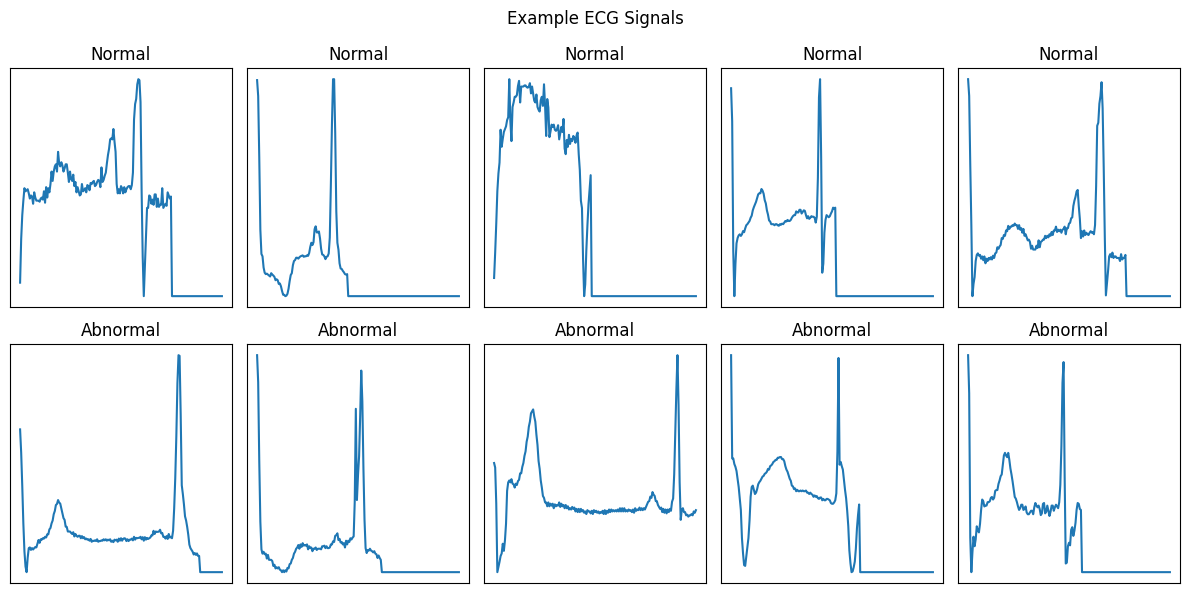

In [10]:
X_train_raw = train_df.iloc[:, :-1].values.astype(np.float32)
y_train_multiclass = train_df.iloc[:, -1].values.astype(int)

X_test_raw = test_df.iloc[:, :-1].values.astype(np.float32)
y_test_multiclass = test_df.iloc[:, -1].values.astype(int)

# Binary anomaly labels: 0 = normal, 1 = abnormal
y_train_binary = (y_train_multiclass != 0).astype(int)
y_test_binary = (y_test_multiclass != 0).astype(int)

def plot_ecg_examples(X, y_binary, title, n=5):
    normal_indices = np.where(y_binary == 0)[0]
    abnormal_indices = np.where(y_binary == 1)[0]
    
    normal_sample = np.random.choice(normal_indices, size=n, replace=False)
    abnormal_sample = np.random.choice(abnormal_indices, size=n, replace=False)
    
    plt.figure(figsize=(12, 6))
    
    for i, idx in enumerate(normal_sample):
        plt.subplot(2, n, i + 1)
        plt.plot(X[idx])
        plt.title("Normal")
        plt.xticks([])
        plt.yticks([])
    
    for i, idx in enumerate(abnormal_sample):
        plt.subplot(2, n, n + i + 1)
        plt.plot(X[idx])
        plt.title("Abnormal")
        plt.xticks([])
        plt.yticks([])
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_ecg_examples(X_train_raw, y_train_binary, "Example ECG Signals")

## ECG Signal Examples

The signal plots show examples of normal and abnormal heartbeat segments.

Each row is a one-dimensional ECG signal over time.

The goal of the autoencoder is to learn the typical structure of normal heartbeat signals. Abnormal signals may have different shapes, peaks, or timing patterns, which can lead to higher reconstruction error.

In [11]:
X_train_normal = X_train_raw[y_train_binary == 0]

X_train_normal, X_val_normal = train_test_split(
    X_train_normal,
    test_size=0.2,
    random_state=SEED
)

print("Normal train samples:", X_train_normal.shape)
print("Normal validation samples:", X_val_normal.shape)

Normal train samples: (57976, 187)
Normal validation samples: (14495, 187)


## Normal-Only Training Split

The autoencoder is trained only on normal heartbeat signals.

The normal heartbeat samples are split into 57,976 training samples and 14,495 validation samples.

The training subset is used to update the autoencoder weights, while the validation subset is used to monitor reconstruction performance on unseen normal signals.

Abnormal samples are kept out of training so that reconstruction error can be used as an anomaly score during testing.

In [12]:
X_train_normal = X_train_raw[y_train_binary == 0]

X_train_normal, X_val_normal = train_test_split(
    X_train_normal,
    test_size=0.2,
    random_state=SEED
)

print("Normal train samples:", X_train_normal.shape)
print("Normal validation samples:", X_val_normal.shape)

Normal train samples: (57976, 187)
Normal validation samples: (14495, 187)


## Normal-Only Training Split

The autoencoder is trained only on normal heartbeat signals.

The normal training samples are split into a training subset and a validation subset.

The training subset updates the autoencoder weights, while the validation subset monitors whether the model can reconstruct unseen normal signals.

Abnormal samples are kept out of training so that high reconstruction error can be used as an anomaly signal.

In [13]:
scaler = StandardScaler()

X_train_normal_scaled = scaler.fit_transform(X_train_normal)
X_val_normal_scaled = scaler.transform(X_val_normal)

X_test_scaled = scaler.transform(X_test_raw)

print("Scaled train mean:", X_train_normal_scaled.mean())
print("Scaled train std:", X_train_normal_scaled.std())

Scaled train mean: 2.0267152e-10
Scaled train std: 1.0


## Scaling

The ECG signal values are standardized using only the normal training data.

This is important because the autoencoder should learn the distribution of normal signals.

The same scaler is then applied to validation and test samples.

Fitting the scaler only on normal training data avoids leaking information from abnormal or test samples into the training process.

In [14]:
BATCH_SIZE = 256

train_tensor = torch.tensor(X_train_normal_scaled, dtype=torch.float32)
val_tensor = torch.tensor(X_val_normal_scaled, dtype=torch.float32)
test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

train_dataset = TensorDataset(train_tensor, train_tensor)
val_dataset = TensorDataset(val_tensor, val_tensor)
test_dataset = TensorDataset(test_tensor, test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

input_dim = X_train_normal_scaled.shape[1]
input_dim

187

## Autoencoder Datasets

For an autoencoder, the input and target are the same.

The model receives an ECG signal and tries to reconstruct that same signal.

The training dataset therefore stores pairs in the form:

```text
input signal → same signal

In [15]:
class DenseAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )
    
    def forward(self, x):
        z = self.encoder(x)
        reconstructed = self.decoder(z)
        return reconstructed

In [16]:
LATENT_DIM = 16

autoencoder = DenseAutoencoder(
    input_dim=input_dim,
    latent_dim=LATENT_DIM
).to(device)

sample_batch, _ = next(iter(train_loader))
sample_batch = sample_batch.to(device)

with torch.no_grad():
    sample_recon = autoencoder(sample_batch)

print("Input shape:", sample_batch.shape)
print("Reconstruction shape:", sample_recon.shape)

Input shape: torch.Size([256, 187])
Reconstruction shape: torch.Size([256, 187])


## Dense Autoencoder Architecture

The autoencoder has two main parts:

- Encoder
- Decoder

The encoder compresses the ECG signal into a smaller latent representation.

The decoder reconstructs the original ECG signal from that compressed representation.

The bottleneck forces the model to learn a compact representation of normal heartbeat patterns.

If an abnormal heartbeat does not match the learned normal structure, the reconstruction error should be higher.

In [17]:
def train_autoencoder_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    
    total_loss = 0.0
    total_samples = 0
    
    for inputs, targets in dataloader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * inputs.size(0)
        total_samples += inputs.size(0)
    
    return total_loss / total_samples

In [18]:
def evaluate_autoencoder(model, dataloader, criterion, device):
    model.eval()
    
    total_loss = 0.0
    total_samples = 0
    
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            total_loss += loss.item() * inputs.size(0)
            total_samples += inputs.size(0)
    
    return total_loss / total_samples

## Autoencoder Training Loop

The autoencoder is trained using reconstruction loss.

For each batch:

1. The model receives an ECG signal.
2. The encoder compresses the signal into a latent vector.
3. The decoder reconstructs the signal.
4. The reconstruction is compared with the original input.
5. The model weights are updated to reduce reconstruction error.

Mean squared error is used as the reconstruction loss.

In [19]:
criterion = nn.MSELoss()

optimizer = optim.Adam(
    autoencoder.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

EPOCHS = 30

history = {
    "train_loss": [],
    "val_loss": []
}

best_val_loss = float("inf")
best_model_state = None

for epoch in range(EPOCHS):
    train_loss = train_autoencoder_epoch(
        autoencoder,
        train_loader,
        criterion,
        optimizer,
        device
    )
    
    val_loss = evaluate_autoencoder(
        autoencoder,
        val_loader,
        criterion,
        device
    )
    
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = autoencoder.state_dict()
    
    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

autoencoder.load_state_dict(best_model_state)
print("Best validation loss:", best_val_loss)

Epoch 1/30 | Train Loss: 0.402391 | Val Loss: 0.230533
Epoch 2/30 | Train Loss: 0.185772 | Val Loss: 0.146609
Epoch 3/30 | Train Loss: 0.129978 | Val Loss: 0.114759
Epoch 4/30 | Train Loss: 0.105987 | Val Loss: 0.096077
Epoch 5/30 | Train Loss: 0.091003 | Val Loss: 0.085256
Epoch 6/30 | Train Loss: 0.081827 | Val Loss: 0.077830
Epoch 7/30 | Train Loss: 0.075166 | Val Loss: 0.071735
Epoch 8/30 | Train Loss: 0.069847 | Val Loss: 0.067305
Epoch 9/30 | Train Loss: 0.065668 | Val Loss: 0.062994
Epoch 10/30 | Train Loss: 0.062178 | Val Loss: 0.060648
Epoch 11/30 | Train Loss: 0.059434 | Val Loss: 0.058195
Epoch 12/30 | Train Loss: 0.056742 | Val Loss: 0.055905
Epoch 13/30 | Train Loss: 0.054674 | Val Loss: 0.053703
Epoch 14/30 | Train Loss: 0.052855 | Val Loss: 0.052697
Epoch 15/30 | Train Loss: 0.051395 | Val Loss: 0.051220
Epoch 16/30 | Train Loss: 0.049878 | Val Loss: 0.049338
Epoch 17/30 | Train Loss: 0.049105 | Val Loss: 0.048706
Epoch 18/30 | Train Loss: 0.047349 | Val Loss: 0.047149
E

## Training Results

The autoencoder was trained for 30 epochs using only normal heartbeat signals.

The training loss decreased from 0.4024 in epoch 1 to 0.0390 in epoch 30. The validation loss also decreased from 0.2305 to 0.0391.

The best validation loss achieved was 0.0391.

The training and validation losses decreased together throughout most of training, which suggests that the model learned a useful compressed representation of normal heartbeat patterns.

There is no strong sign of severe overfitting because the validation loss continued improving and stayed close to the training loss.

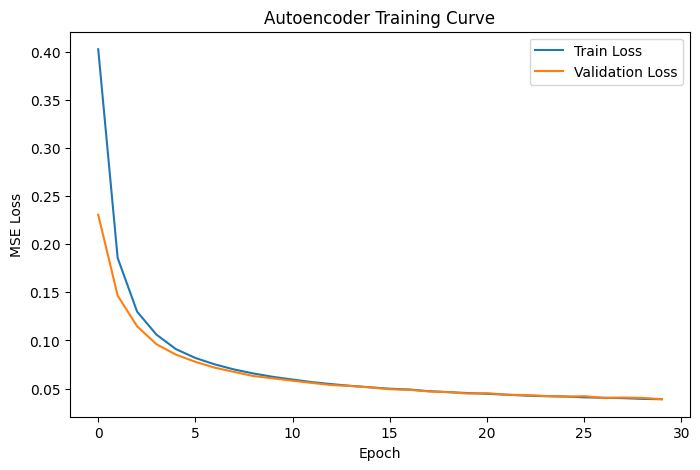

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("Autoencoder Training Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

## Training Curve

The training curve shows how reconstruction loss changes over time.

A decreasing loss means the autoencoder is learning to reconstruct normal ECG signals more accurately.

The validation loss is especially important because it measures reconstruction performance on unseen normal signals.

A stable validation curve suggests that the learned representation generalizes beyond the training samples.

In [21]:
def reconstruct_samples(model, X_scaled, n=5):
    model.eval()
    
    indices = np.random.choice(len(X_scaled), size=n, replace=False)
    samples = torch.tensor(X_scaled[indices], dtype=torch.float32).to(device)
    
    with torch.no_grad():
        recon = model(samples).cpu().numpy()
    
    return indices, samples.cpu().numpy(), recon

In [22]:
normal_test_indices = np.where(y_test_binary == 0)[0]
abnormal_test_indices = np.where(y_test_binary == 1)[0]

normal_scaled = X_test_scaled[normal_test_indices]
abnormal_scaled = X_test_scaled[abnormal_test_indices]

In [23]:
def plot_reconstructions(original, reconstructed, title):
    n = len(original)
    
    plt.figure(figsize=(12, 2.5 * n))
    
    for i in range(n):
        plt.subplot(n, 1, i + 1)
        plt.plot(original[i], label="Original", alpha=0.8)
        plt.plot(reconstructed[i], label="Reconstructed", alpha=0.8)
        plt.title(f"{title} Example {i + 1}")
        plt.legend()
    
    plt.tight_layout()
    plt.show()

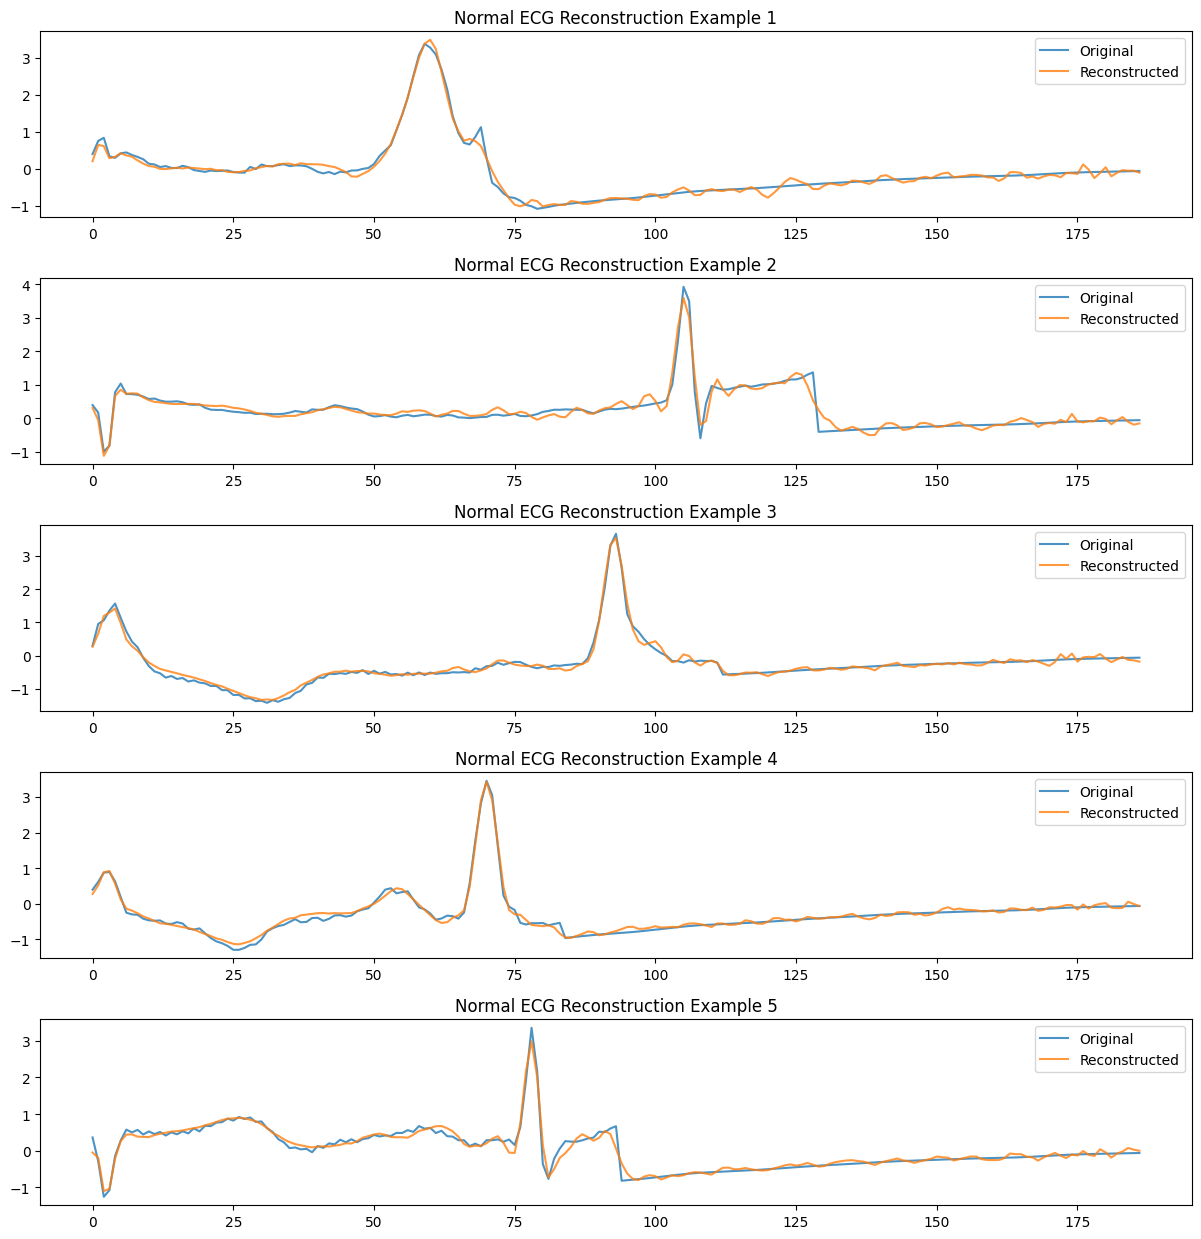

In [24]:
_, normal_original, normal_recon = reconstruct_samples(
    autoencoder,
    normal_scaled,
    n=5
)

plot_reconstructions(
    normal_original,
    normal_recon,
    "Normal ECG Reconstruction"
)

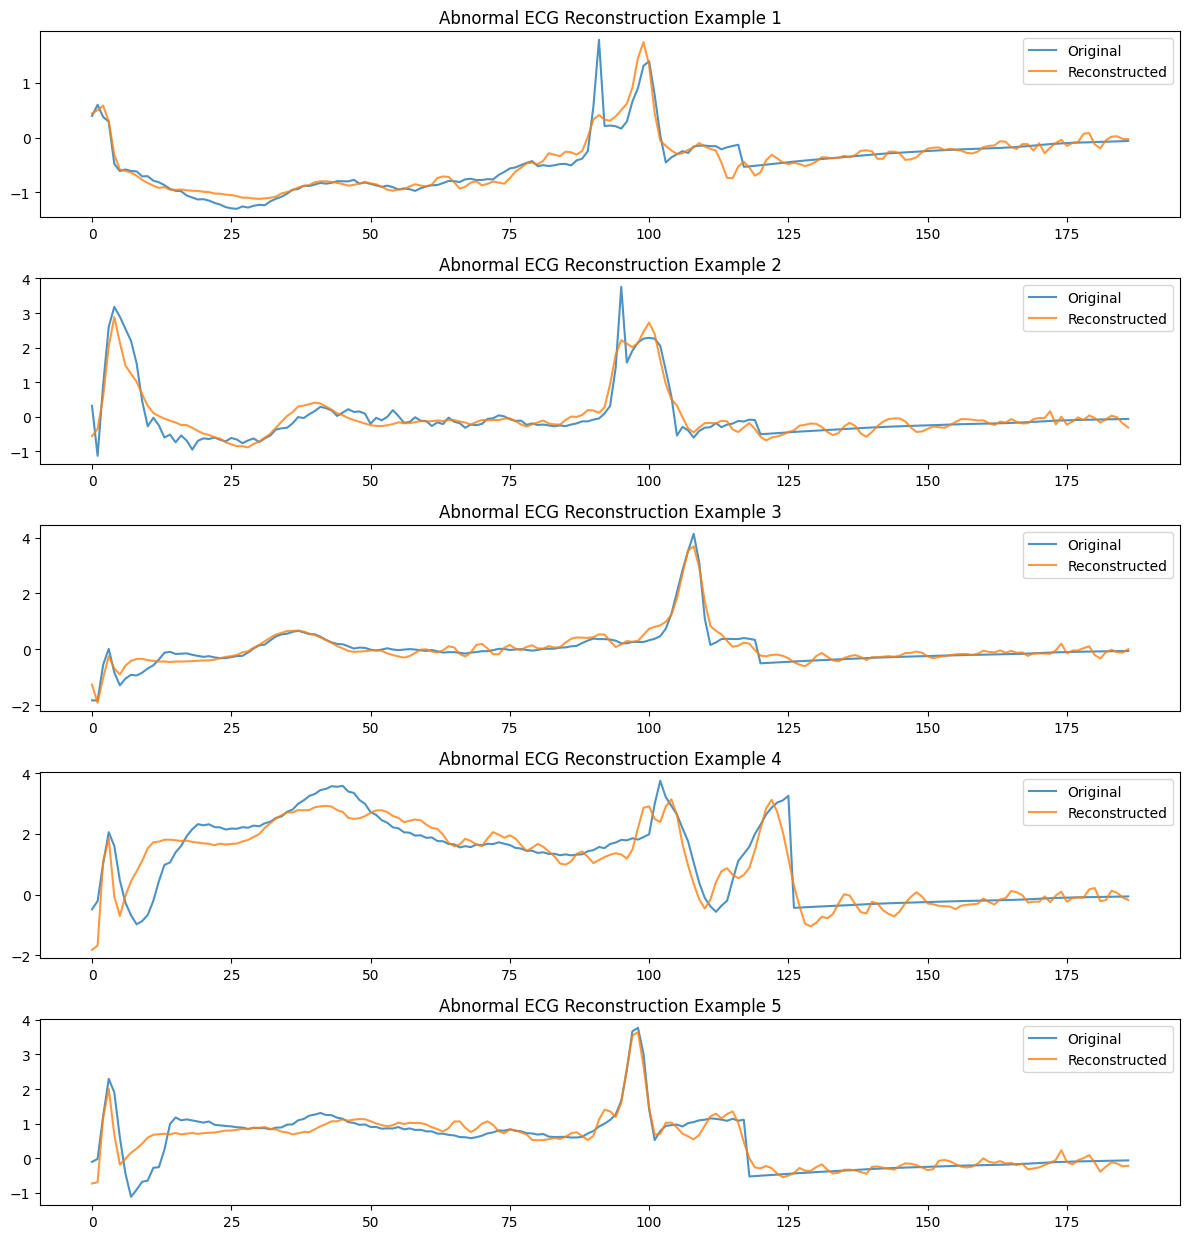

In [25]:
_, abnormal_original, abnormal_recon = reconstruct_samples(
    autoencoder,
    abnormal_scaled,
    n=5
)

plot_reconstructions(
    abnormal_original,
    abnormal_recon,
    "Abnormal ECG Reconstruction"
)

## Reconstruction Examples

The reconstruction plots compare original ECG signals with the autoencoder outputs.

For normal signals, the reconstruction should usually follow the original shape reasonably well because the model was trained on normal heartbeat patterns.

For abnormal signals, the reconstruction may be less accurate because the model has not learned those patterns during training.

This visual comparison helps connect the anomaly detection idea to the actual signal shapes.

In [26]:
def calculate_reconstruction_errors(model, X_scaled, device):
    model.eval()
    
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)
    
    errors = []
    
    with torch.no_grad():
        for i in range(0, len(X_tensor), 1024):
            batch = X_tensor[i:i+1024]
            recon = model(batch)
            batch_errors = torch.mean((batch - recon) ** 2, dim=1)
            errors.extend(batch_errors.cpu().numpy())
    
    return np.array(errors)

In [27]:
test_errors = calculate_reconstruction_errors(
    autoencoder,
    X_test_scaled,
    device
)

normal_errors = test_errors[y_test_binary == 0]
abnormal_errors = test_errors[y_test_binary == 1]

print("Normal reconstruction error summary:")
print(pd.Series(normal_errors).describe())

print("\nAbnormal reconstruction error summary:")
print(pd.Series(abnormal_errors).describe())

Normal reconstruction error summary:
count    18118.000000
mean         0.038769
std          0.073109
min          0.002740
25%          0.011948
50%          0.021322
75%          0.038232
max          3.251964
dtype: float64

Abnormal reconstruction error summary:
count    3774.000000
mean        0.169777
std         0.214436
min         0.003079
25%         0.065564
50%         0.115164
75%         0.205021
max         3.916764
dtype: float64


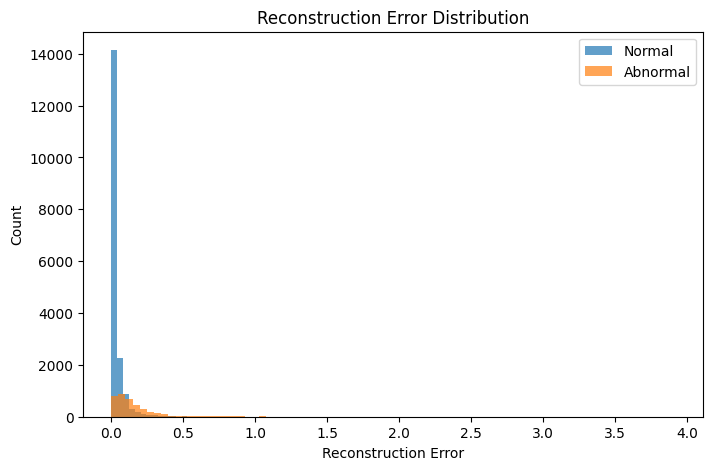

In [28]:
plt.figure(figsize=(8, 5))
plt.hist(normal_errors, bins=80, alpha=0.7, label="Normal")
plt.hist(abnormal_errors, bins=80, alpha=0.7, label="Abnormal")
plt.title("Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.legend()
plt.show()

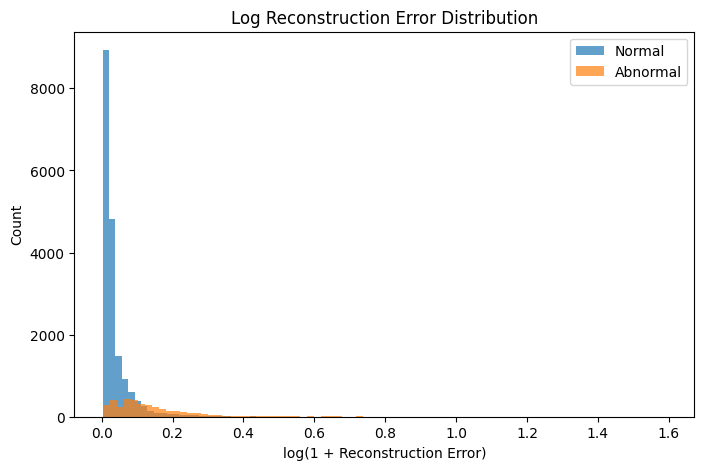

In [29]:
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(normal_errors), bins=80, alpha=0.7, label="Normal")
plt.hist(np.log1p(abnormal_errors), bins=80, alpha=0.7, label="Abnormal")
plt.title("Log Reconstruction Error Distribution")
plt.xlabel("log(1 + Reconstruction Error)")
plt.ylabel("Count")
plt.legend()
plt.show()

## Reconstruction Error Distribution

Reconstruction error is the main anomaly score in this notebook.

A higher reconstruction error means the autoencoder had more difficulty reconstructing the heartbeat signal.

Normal heartbeats had a much lower average reconstruction error, with a mean error of 0.0388 and a median error of 0.0213.

Abnormal heartbeats had a higher average reconstruction error, with a mean error of 0.1698 and a median error of 0.1152.

This shows that abnormal signals generally produce higher reconstruction errors than normal signals.

However, the distributions still overlap. Some abnormal heartbeats have low reconstruction error, and some normal heartbeats have unusually high reconstruction error. This means reconstruction error is useful for anomaly detection, but it is not a perfect separator.

In [30]:
val_errors = calculate_reconstruction_errors(
    autoencoder,
    X_val_normal_scaled,
    device
)

threshold_95 = np.percentile(val_errors, 95)
threshold_99 = np.percentile(val_errors, 99)

print("95th percentile threshold:", threshold_95)
print("99th percentile threshold:", threshold_99)

95th percentile threshold: 0.12275749
99th percentile threshold: 0.30154318


In [31]:
def evaluate_threshold(y_true, errors, threshold):
    y_pred = (errors >= threshold).astype(int)
    
    return {
        "threshold": threshold,
        "predicted_anomalies": int(y_pred.sum()),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

threshold_results = pd.DataFrame([
    evaluate_threshold(y_test_binary, test_errors, threshold_95),
    evaluate_threshold(y_test_binary, test_errors, threshold_99)
])

threshold_results

,threshold,predicted_anomalies,precision,recall,f1
0,0.122757,2668,0.668666,0.472708,0.553865
1,0.301543,627,0.740032,0.122946,0.210861


## Threshold Selection

The autoencoder produces a continuous reconstruction error, not a class label.

A threshold is needed to convert reconstruction error into a normal or abnormal prediction.

This notebook uses thresholds based on reconstruction errors from normal validation samples:

- 95th percentile threshold: 0.1228
- 99th percentile threshold: 0.3015

At the 95th percentile threshold, the model predicted 2,668 anomalies. It achieved precision of 0.6687, recall of 0.4727, and F1-score of 0.5539.

At the 99th percentile threshold, the model predicted only 627 anomalies. Precision increased to 0.7400, but recall dropped sharply to 0.1229, giving an F1-score of 0.2109.

This shows the expected threshold trade-off. The 95th percentile threshold catches more abnormal heartbeats, while the 99th percentile threshold is stricter and produces fewer false alarms but misses many more abnormal cases.

In [32]:
roc_auc = roc_auc_score(y_test_binary, test_errors)
pr_auc = average_precision_score(y_test_binary, test_errors)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.867862868647756
PR-AUC: 0.5966117590994775


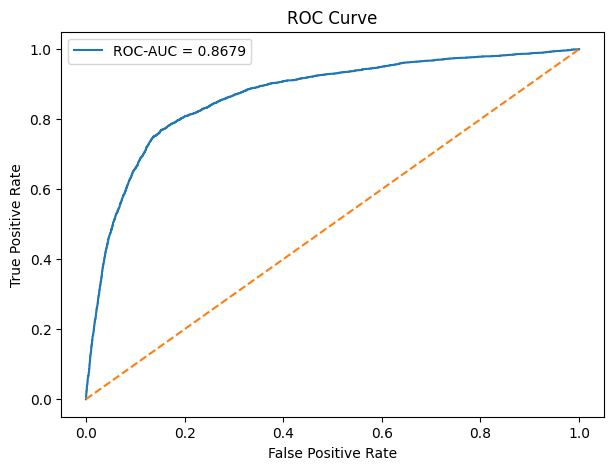

In [33]:
fpr, tpr, _ = roc_curve(y_test_binary, test_errors)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

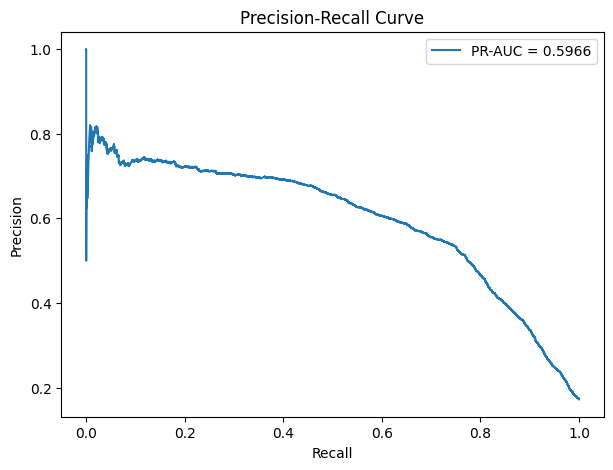

In [34]:
precision, recall, _ = precision_recall_curve(y_test_binary, test_errors)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

## ROC-AUC and PR-AUC

ROC-AUC and PR-AUC evaluate reconstruction error as an anomaly score across many possible thresholds.

ROC-AUC measures how well the model ranks abnormal signals above normal signals.

PR-AUC focuses more directly on the abnormal class and is useful when the classes are imbalanced.

The autoencoder achieved a ROC-AUC of 0.8679 and a PR-AUC of 0.5966.

These results show that reconstruction error is useful for separating normal and abnormal heartbeat signals. The ROC-AUC is strong, meaning abnormal samples often receive higher reconstruction errors than normal samples.

The PR-AUC is lower than the ROC-AUC because the abnormal class is less common and because there is overlap between normal and abnormal reconstruction errors.

In [35]:
final_threshold = threshold_95

final_pred = (test_errors >= final_threshold).astype(int)

print("Final threshold:", final_threshold)
print("Confusion matrix:")
print(confusion_matrix(y_test_binary, final_pred))

print("\nClassification report:")
print(classification_report(y_test_binary, final_pred, digits=4))

Final threshold: 0.12275749
Confusion matrix:
[[17234   884]
 [ 1990  1784]]

Classification report:
              precision    recall  f1-score   support

           0     0.8965    0.9512    0.9230     18118
           1     0.6687    0.4727    0.5539      3774

    accuracy                         0.8687     21892
   macro avg     0.7826    0.7120    0.7385     21892
weighted avg     0.8572    0.8687    0.8594     21892



## Final Threshold Evaluation

The final threshold is selected using the 95th percentile of normal validation reconstruction errors.

Using a threshold of 0.1228, the model classifies test samples as abnormal when their reconstruction error is above the threshold.

The model achieved:

- Accuracy: 0.8687
- Abnormal precision: 0.6687
- Abnormal recall: 0.4727
- Abnormal F1-score: 0.5539

The confusion matrix shows that the model correctly identified 1,784 abnormal heartbeats, while missing 1,990 abnormal heartbeats. It also incorrectly flagged 884 normal heartbeats as abnormal.

This threshold gives a moderate balance between precision and recall. It is better for catching abnormal signals than the stricter 99th percentile threshold, but it still misses a large number of abnormal heartbeats.

A lower threshold would increase recall, while a higher threshold would increase precision.

In [36]:
results_df = pd.DataFrame({
    "true_label": y_test_binary,
    "multiclass_label": y_test_multiclass,
    "reconstruction_error": test_errors
})

results_df = results_df.sort_values("reconstruction_error", ascending=False)

results_df.head(20)

,true_label,multiclass_label,reconstruction_error
19750,1,2,3.916764
18575,1,1,3.722302
11037,0,0,3.251964
3705,0,0,3.122917
20104,1,2,2.832550
19670,1,2,2.472136
19980,1,2,2.331435
13062,0,0,2.240700
19342,1,2,1.981515
18615,1,1,1.919873


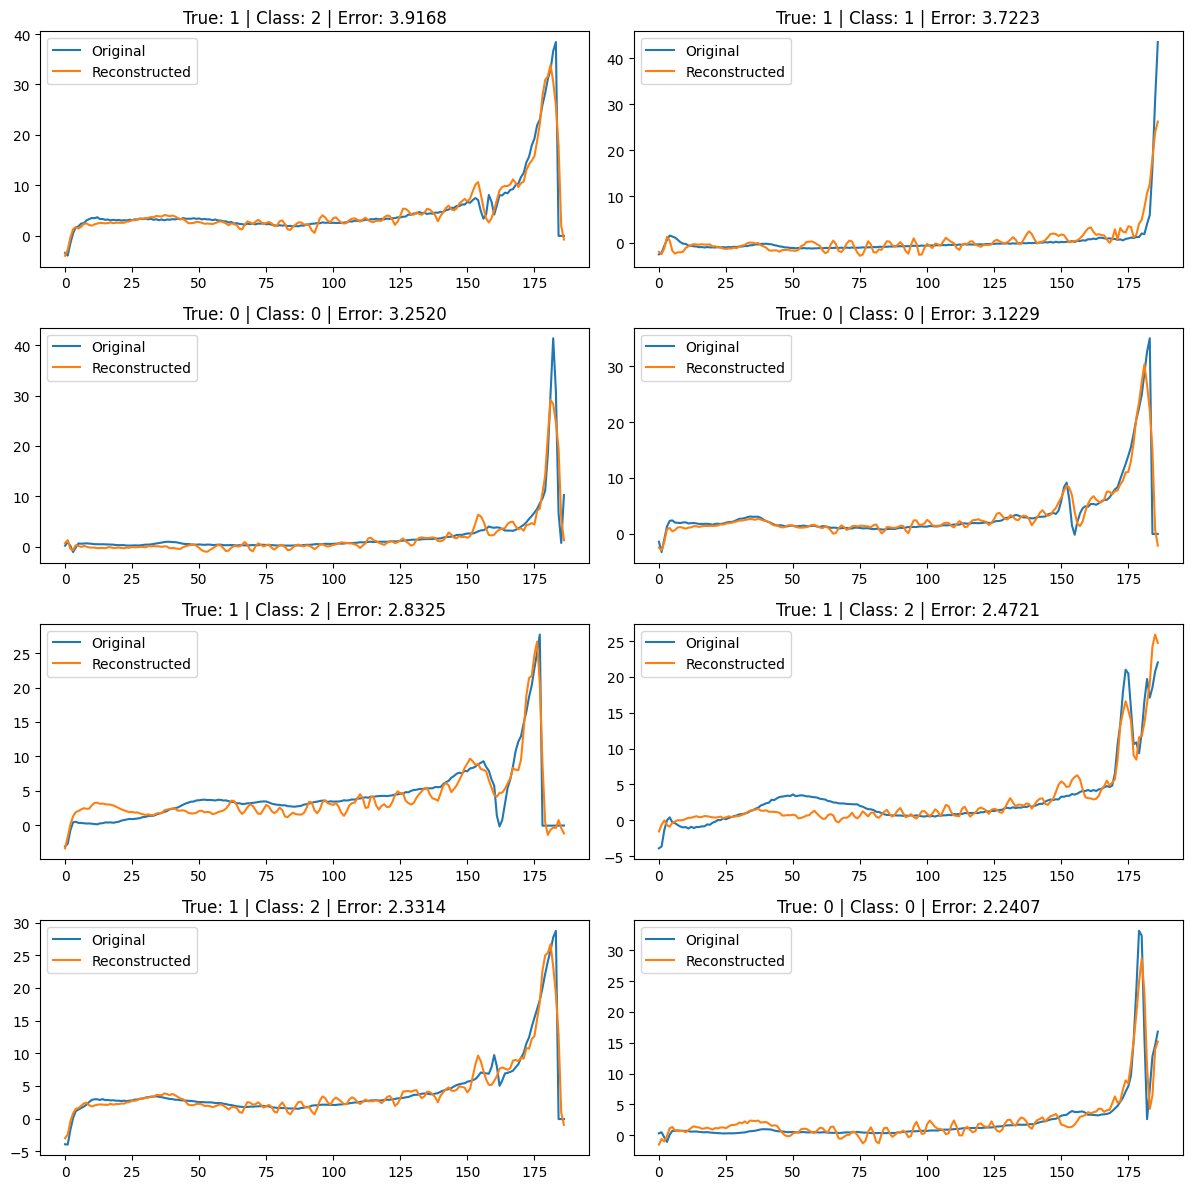

In [37]:
top_error_indices = results_df.head(8).index.tolist()

plt.figure(figsize=(12, 12))

for i, idx in enumerate(top_error_indices):
    original = X_test_scaled[idx]
    
    sample_tensor = torch.tensor(original, dtype=torch.float32).unsqueeze(0).to(device)
    
    with torch.no_grad():
        recon = autoencoder(sample_tensor).cpu().numpy()[0]
    
    plt.subplot(4, 2, i + 1)
    plt.plot(original, label="Original")
    plt.plot(recon, label="Reconstructed")
    plt.title(
        f"True: {y_test_binary[idx]} | "
        f"Class: {y_test_multiclass[idx]} | "
        f"Error: {test_errors[idx]:.4f}"
    )
    plt.legend()

plt.tight_layout()
plt.show()

## Highest-Error Signal Inspection

The highest reconstruction error samples are inspected manually.

These are the signals the autoencoder found most difficult to reconstruct.

If the autoencoder is working well as an anomaly detector, many of the highest-error examples should be abnormal heartbeats.

This step helps connect the numerical anomaly score back to the original ECG signal shape.

In [ ]:
def get_latent_vectors(model, X_scaled, device):
    model.eval()
    
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)
    latents = []
    
    with torch.no_grad():
        for i in range(0, len(X_tensor), 1024):
            batch = X_tensor[i:i+1024]
            z = model.encoder(batch)
            latents.extend(z.cpu().numpy())
    
    return np.array(latents)

test_latents = get_latent_vectors(
    autoencoder,
    X_test_scaled,
    device
)

test_latents.shape

(21892, 16)

In [39]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=SEED)
latent_2d = pca.fit_transform(test_latents)

print("PCA explained variance:", pca.explained_variance_ratio_.sum())

PCA explained variance: 0.6407882


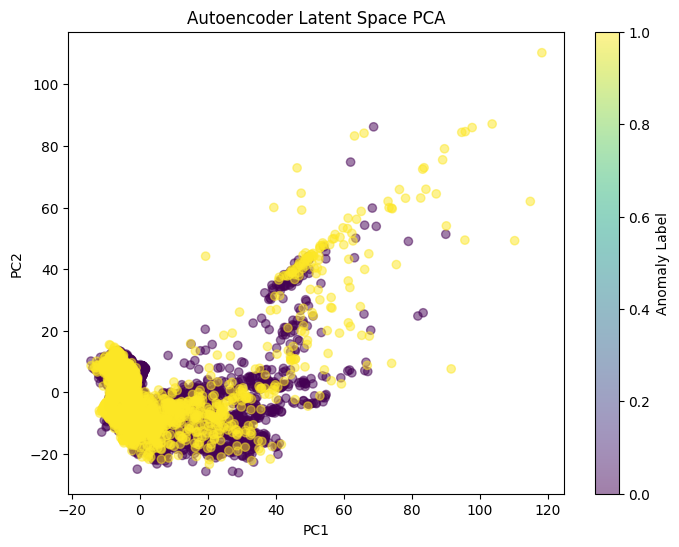

In [40]:
plt.figure(figsize=(8, 6))
plt.scatter(
    latent_2d[:, 0],
    latent_2d[:, 1],
    c=y_test_binary,
    alpha=0.5
)
plt.title("Autoencoder Latent Space PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Anomaly Label")
plt.show()

## Latent Representation Visualization

The encoder compresses each ECG signal into a 16-dimensional latent vector.

These latent vectors represent the autoencoder's learned compressed representation of heartbeat shape.

The latent matrix for the test set has shape `(21892, 16)`, meaning each of the 21,892 test heartbeats is represented using 16 learned features.

PCA is used to project the latent vectors into two dimensions for visualization.

The first two PCA components explain approximately 64.08% of the latent variance.

This suggests that much of the learned latent structure can be viewed in two dimensions, although some information is still stored in the remaining latent dimensions.

If normal and abnormal samples appear partially separated in the latent plot, it suggests that the autoencoder has learned representations that capture meaningful differences between heartbeat types.